# Bước 3: Phân cụm hai giai đoạn - Tách B2B và K-Means++ (k=4)

Notebook này thực hiện pipeline phân cụm hai giai đoạn:

- **Giai đoạn 1** (hoàn thành trong `02_feature_engineering.ipynb`): Bộ lọc B2B dựa trên quy tắc cô lập 179 tài khoản bán buôn (SKU_HHI > 0,5 trên đặc trưng thô)
- **Giai đoạn 2** (notebook này): K-Means++ k=4 trên nhóm retail (3.741 khách hàng, 14 đặc trưng hành vi)

Việc chọn k=4 được chứng minh bằng quét chỉ số qua k=2..6, kết hợp với lập luận về tính hữu ích thương mại.

## Cài đặt

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT / "src"))

from clustering_library import DataVisualizer
from notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical

# Read 02's outputs from the sandbox if a manual run produced them, else canonical.
SCALED_PATH        = rpath("processed/customer_features_scaled.csv")
RETAIL_SCALED_PATH = rpath("processed/customer_features_retail_scaled.csv")
B2B_IDS_PATH       = rpath("processed/b2b_customer_ids.csv")
FIG_DIR = ROOT / "figures" / "03_modeling"
FIG_DIR.mkdir(parents=True, exist_ok=True)

visualizer = DataVisualizer()

## 1. Tải dữ liệu

In [2]:
# Load scaled features (all 3,920 customers)
df_scaled = pd.read_csv(SCALED_PATH, index_col='CustomerID')

# Load retail cohort (B2B already excluded)
df_retail = pd.read_csv(RETAIL_SCALED_PATH, index_col='CustomerID')

# Load B2B IDs
b2b_ids = pd.read_csv(B2B_IDS_PATH)['CustomerID'].values

print(f"Full population : {df_scaled.shape[0]:,} customers × {df_scaled.shape[1]} features")
print(f"B2B accounts    : {len(b2b_ids):,} ({100*len(b2b_ids)/len(df_scaled):.1f}%)")
print(f"Retail cohort   : {df_retail.shape[0]:,} customers ({100*df_retail.shape[0]/len(df_scaled):.1f}%)")

df_retail.head()

Full population : 3,920 customers × 14 features
B2B accounts    : 179 (4.6%)
Retail cohort   : 3,741 customers (95.4%)


,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,RepeatSKUFraction,BasketSizeCV,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,SpendAcceleration,QuarterConcentration
CustomerID,,,,,,,,,,,,,,
12747,-0.847101,0.522824,-0.162346,0.321059,-0.181351,0.759908,0.398952,0.078759,-0.040204,-0.186333,0.367973,-0.518984,0.712658,-0.627314
12748,-1.732051,1.009889,1.732051,-0.455417,1.366671,0.829909,0.852455,-0.200760,1.048725,-0.665083,-1.330426,0.800681,1.586956,-0.583028
12749,-0.651966,0.661711,-0.287661,0.945986,0.214517,0.579426,0.627462,-0.079747,0.201618,0.275542,-0.762511,1.015106,-0.756975,-0.672667
12820,-0.740035,0.717881,-0.773731,-0.125903,-0.299437,0.429761,0.397823,0.154809,-0.234525,0.125342,-0.359348,-0.518984,0.681440,-0.543121
12821,0.509246,-0.530921,0.136925,-0.915159,0.596132,-0.822169,-0.923725,0.226332,-0.272004,-0.443138,0.415412,-0.518984,-0.030675,0.781046


## 2. Giai đoạn 1 - Phân khúc B2B (Rule-Based)

Tài khoản giống wholesale (SKU_HHI > 0,5) đã được tách riêng trong `02_feature_engineering.ipynb`. Ở đây ta xem hồ sơ của nhóm này để xác nhận đặc điểm trước khi loại khỏi bước phân cụm.

**Tại sao dùng rule-based thay vì K-Means?**
K-Means tối thiểu hoá tổng phương sai trên cả 14 chiều. Nhóm B2B (4,6%) chỉ nổi bật trên 1-2 đặc trưng (SKU_HHI, BulkLineRate); cấu trúc phương sai chính của dữ liệu là phân chia "thỉnh thoảng vs thường xuyên" của retail. K-Means sẽ để B2B rơi vào cluster "thường xuyên", tạo ra nhóm "Champions" giả. Quy tắc SKU_HHI > 0,5 kiểm tra trực tiếp tín hiệu procurement và có thể giải thích được về mặt kinh doanh.

In [3]:
# B2B vs Retail median comparison (on scaled features)
df_b2b = df_scaled.loc[b2b_ids]

b2b_med    = df_b2b.median()
retail_med = df_retail.median()
diff_df    = pd.DataFrame({'B2B median (z)': b2b_med, 'Retail median (z)': retail_med,
                            'Δ (B2B − Retail)': b2b_med - retail_med})
diff_df = diff_df.sort_values('Δ (B2B − Retail)', ascending=False)
print("B2B vs Retail median (z-scores after scaling):\n")
print(diff_df.round(2).to_string())

B2B vs Retail median (z-scores after scaling):

                      B2B median (z)  Retail median (z)  Δ (B2B − Retail)
SKU_HHI                         1.50              -0.05              1.55
BulkLineRate                    1.38              -0.01              1.38
QuarterConcentration            0.78              -0.46              1.24
Recency                         0.35               0.01              0.34
InterPurchaseCV                -0.53              -0.53              0.00
MonthlyOrderRate                0.14               0.14              0.00
ReturnRate                     -0.52              -0.52              0.00
SpendAcceleration              -0.03              -0.03              0.00
AOV                            -0.43               0.01             -0.44
MedianBasketQty                -0.57               0.02             -0.59
QuantityCV                     -0.63               0.04             -0.67
PriceCV                        -0.84               0.05         

## 3. Giai đoạn 2 - Chọn k cho nhóm retail

Quét k=2..6 trên nhóm retail (3.741 khách hàng, 14 đặc trưng). Ba chỉ số bổ sung nhau:
- **Silhouette** (cao hơn tốt hơn): đo độ gắn kết nội bộ so với khoảng cách liên cluster
- **Davies-Bouldin** (thấp hơn tốt hơn): tỉ lệ trung bình giữa độ phân tán cluster và khoảng cách liên cluster
- **Calinski-Harabasz** (cao hơn tốt hơn): tỉ lệ phương sai giữa cluster và trong cluster

**Điểm tổng hợp** = 0,5 x Silhouette + 0,25 x (1/(1+DB)) + 0,25 x (CH/CH_max)
Trọng số: silhouette có trọng số gấp đôi vì là chỉ số hình học dễ giải thích nhất.

In [4]:
X_retail = df_retail.values

k_range  = range(2, 7)
results  = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_retail)
    sil = silhouette_score(X_retail, labels, random_state=42)
    db  = davies_bouldin_score(X_retail, labels)
    ch  = calinski_harabasz_score(X_retail, labels)
    results.append({'k': k, 'Silhouette': sil, 'DaviesBouldin': db, 'CalinskiHarabasz': ch})
    print(f"k={k}: Sil={sil:.4f}  DB={db:.4f}  CH={ch:.1f}")

metrics_df = pd.DataFrame(results).set_index('k')

# Composite score
ch_max = metrics_df['CalinskiHarabasz'].max()
metrics_df['Composite'] = (
    0.5 * metrics_df['Silhouette']
    + 0.25 / (1 + metrics_df['DaviesBouldin'])
    + 0.25 * metrics_df['CalinskiHarabasz'] / ch_max
)
print("\nMetric sweep (retail cohort, native 14D space):")
print(metrics_df.round(4))

k=2: Sil=0.3151  DB=1.2793  CH=1874.0
k=3: Sil=0.2491  DB=1.8020  CH=1352.1


k=4: Sil=0.2436  DB=1.7641  CH=1066.4


k=5: Sil=0.2424  DB=1.6985  CH=943.1


k=6: Sil=0.1797  DB=1.7716  CH=855.8

Metric sweep (retail cohort, native 14D space):
   Silhouette  DaviesBouldin  CalinskiHarabasz  Composite
k                                                        
2      0.3151         1.2793         1874.0307     0.5172
3      0.2491         1.8020         1352.0581     0.3942
4      0.2436         1.7641         1066.4335     0.3545
5      0.2424         1.6985          943.0770     0.3396
6      0.1797         1.7716          855.7660     0.2942


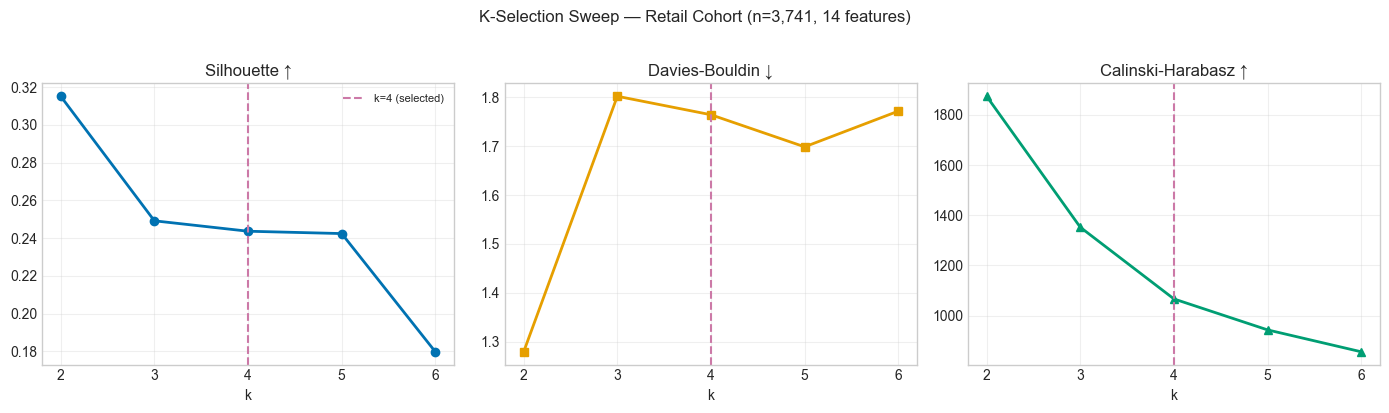

Saved: /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/figures/03_modeling/k_selection_retail.png


In [5]:
# K-selection plot — Wong CVD-safe line colors
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks = metrics_df.index.tolist()

axes[0].plot(ks, metrics_df['Silhouette'], 'o-', color='#0072B2', lw=2)   # Wong blue
axes[0].axvline(4, color='#CC79A7', ls='--', lw=1.5, label='k=4 (selected)')
axes[0].set_title('Silhouette ↑')
axes[0].set_xlabel('k'); axes[0].legend(fontsize=8)

axes[1].plot(ks, metrics_df['DaviesBouldin'], 's-', color='#E69F00', lw=2)  # Wong orange
axes[1].axvline(4, color='#CC79A7', ls='--', lw=1.5)
axes[1].set_title('Davies-Bouldin ↓')
axes[1].set_xlabel('k')

axes[2].plot(ks, metrics_df['CalinskiHarabasz'], '^-', color='#009E73', lw=2)  # Wong green
axes[2].axvline(4, color='#CC79A7', ls='--', lw=1.5)
axes[2].set_title('Calinski-Harabasz ↑')
axes[2].set_xlabel('k')

for ax in axes:
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)

fig.suptitle('K-Selection Sweep — Retail Cohort (n=3,741, 14 features)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'k_selection_retail.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'k_selection_retail.png'}")

## 4. Lý do chọn k=4

**Các chỉ số nội bộ đạt đỉnh tại k=2**: Silhouette, DB, CH đều chỉ k=2 ("người mua thường xuyên vs thỉnh thoảng"). Đây là phân chia hình học hợp lệ, nhưng không đủ để hỗ trợ 4 chiến lược thương mại khác nhau.

**k=4 là k nhỏ nhất giải quyết được cả 4 nhóm:**
- **C0 Seasonal Intensives**: mua dồn theo mùa (Q4), MonthlyOrderRate cao và QuarterConcentration cao
- **C1 High-Return Actives**: ReturnRate trung vị dương; nhóm duy nhất có tín hiệu này; LTV cao nhất
- **C2 One-Time Explorers**: mua đúng một lần (BasketSizeCV≈0, RepeatSKUFraction≈0), Recency cao; single-purchase nên QuarterConcentration≈1
- **C3 Occasional Loyalists**: không hoàn trả (ReturnRate 0), gắn bó lâu, tần suất vừa phải

**k=3 gộp One-Time Explorers và Seasonal Intensives thành một nhóm** (đa số không hoàn trả). Heatmap bên dưới cho thấy các đặc trưng `QuarterConcentration`, `MonthlyOrderRate`, `InterPurchaseCV` là tín hiệu mà k=4 mới phân tách được. `ReturnRate` đã được tách từ k=3.

In [6]:
# ReturnRate axis: already resolved at k=3 (one cluster at +1.28), retained at k=4
km3 = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42).fit(X_retail)
km4 = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42).fit(X_retail)

feat_cols = df_retail.columns.tolist()
rr_idx = feat_cols.index('ReturnRate')

print("ReturnRate median (scaled) per cluster:")
print("\nk=3:")
for c in range(3):
    mask = km3.labels_ == c
    med  = np.median(X_retail[mask, rr_idx])
    print(f"  C{c} (n={mask.sum():4d}): ReturnRate median = {med:+.2f}")

print("\nk=4:")
for c in range(4):
    mask = km4.labels_ == c
    med  = np.median(X_retail[mask, rr_idx])
    print(f"  C{c} (n={mask.sum():4d}): ReturnRate median = {med:+.2f}")

ReturnRate median (scaled) per cluster:

k=3:
  C0 (n=1243): ReturnRate median = -0.52
  C1 (n=1338): ReturnRate median = -0.52
  C2 (n=1160): ReturnRate median = +0.91

k=4:
  C0 (n=1047): ReturnRate median = -0.52
  C1 (n=1107): ReturnRate median = +0.91
  C2 (n=1257): ReturnRate median = -0.52
  C3 (n= 330): ReturnRate median = -0.52


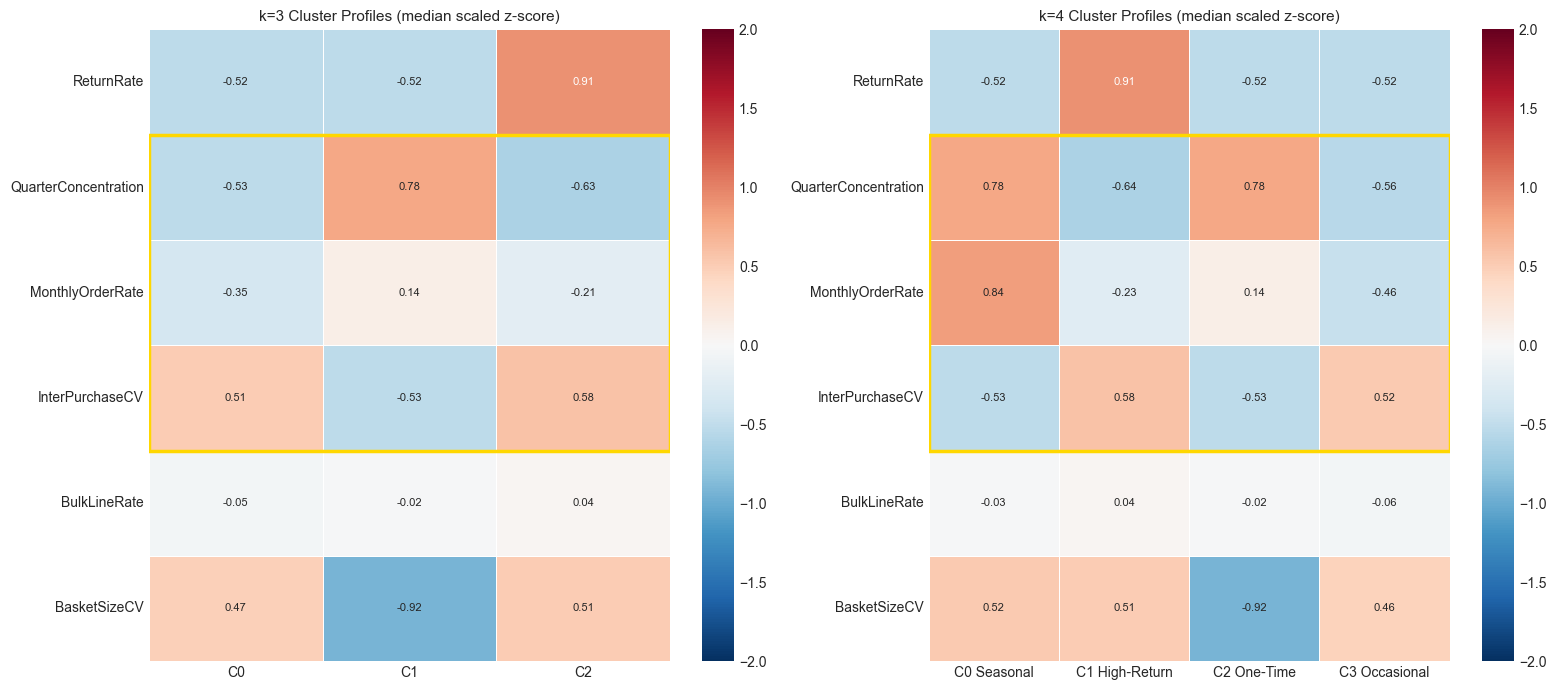

Saved: /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/figures/03_modeling/k_compare_retail_3_4.png


In [7]:
# k=3 vs k=4 cluster profile comparison heatmap
# Gold box = cadence/seasonality rows (QuarterConcentration, MonthlyOrderRate, InterPurchaseCV):
# the signal k=4 newly resolves. ReturnRate is already separated at k=3 (see previous cell).
# Show median scaled feature value per cluster for both solutions side by side

def cluster_medians(X, labels, feat_cols):
    df = pd.DataFrame(X, columns=feat_cols)
    df['cluster'] = labels
    return df.groupby('cluster').median()

med3 = cluster_medians(X_retail, km3.labels_, feat_cols)
med4 = cluster_medians(X_retail, km4.labels_, feat_cols)

# Select top-12 most discriminating features for the comparison
top_feats = ['ReturnRate', 'ReturnValueRate', 'ActiveSpanDays', 'SpendGini',
             'BurstIndex', 'MaxSpendShare', 'QuarterConcentration', 'MonthlyOrderRate',
             'InterPurchaseCV', 'BulkLineRate', 'NewSKURate', 'BasketSizeCV']
top_feats = [f for f in top_feats if f in feat_cols]

# Contiguous block of cadence/seasonality rows to highlight
hl_feats = ['QuarterConcentration', 'MonthlyOrderRate', 'InterPurchaseCV']

# Canonical k=4 column order (same content heuristic as the final fit) so labels
# match cluster identity: Seasonal (burst cadence, max MonthlyOrderRate), High-Return
# (max ReturnRate), One-Time (BasketSizeCV≈0, single purchase), Occasional (leftover).
def _canon_order(med_raw):
    c1 = med_raw['ReturnRate'].idxmax()
    rem = [l for l in med_raw.index if l != c1]
    c2 = med_raw.loc[rem, 'BasketSizeCV'].idxmin()
    rem = [l for l in rem if l != c2]
    c0 = med_raw.loc[rem, 'MonthlyOrderRate'].idxmax()
    c3 = [l for l in rem if l != c0][0]
    return [c0, c1, c2, c3]

order4 = _canon_order(med4)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
panels = [
    (axes[0], med3, med3.index.tolist(), ['C0', 'C1', 'C2'], 3),
    (axes[1], med4, order4,
     ['C0 Seasonal', 'C1 High-Return', 'C2 One-Time', 'C3 Occasional'], 4),
]
for ax, med, order, labels_k, k in panels:
    data = med.loc[order, top_feats].T
    data.columns = labels_k
    sns.heatmap(data, ax=ax, cmap='RdBu_r', center=0, vmin=-2, vmax=2,
                annot=True, fmt='.2f', linewidths=0.4, annot_kws={'size': 8})
    ax.set_title(f'k={k} Cluster Profiles (median scaled z-score)', fontsize=11)
    if all(f in top_feats for f in hl_feats):
        hl_start = top_feats.index(hl_feats[0])
        ax.add_patch(plt.Rectangle((0, hl_start), k, len(hl_feats), fill=False,
                                   edgecolor='gold', lw=2.5))

plt.tight_layout()
plt.savefig(FIG_DIR / 'k_compare_retail_3_4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", FIG_DIR / 'k_compare_retail_3_4.png')

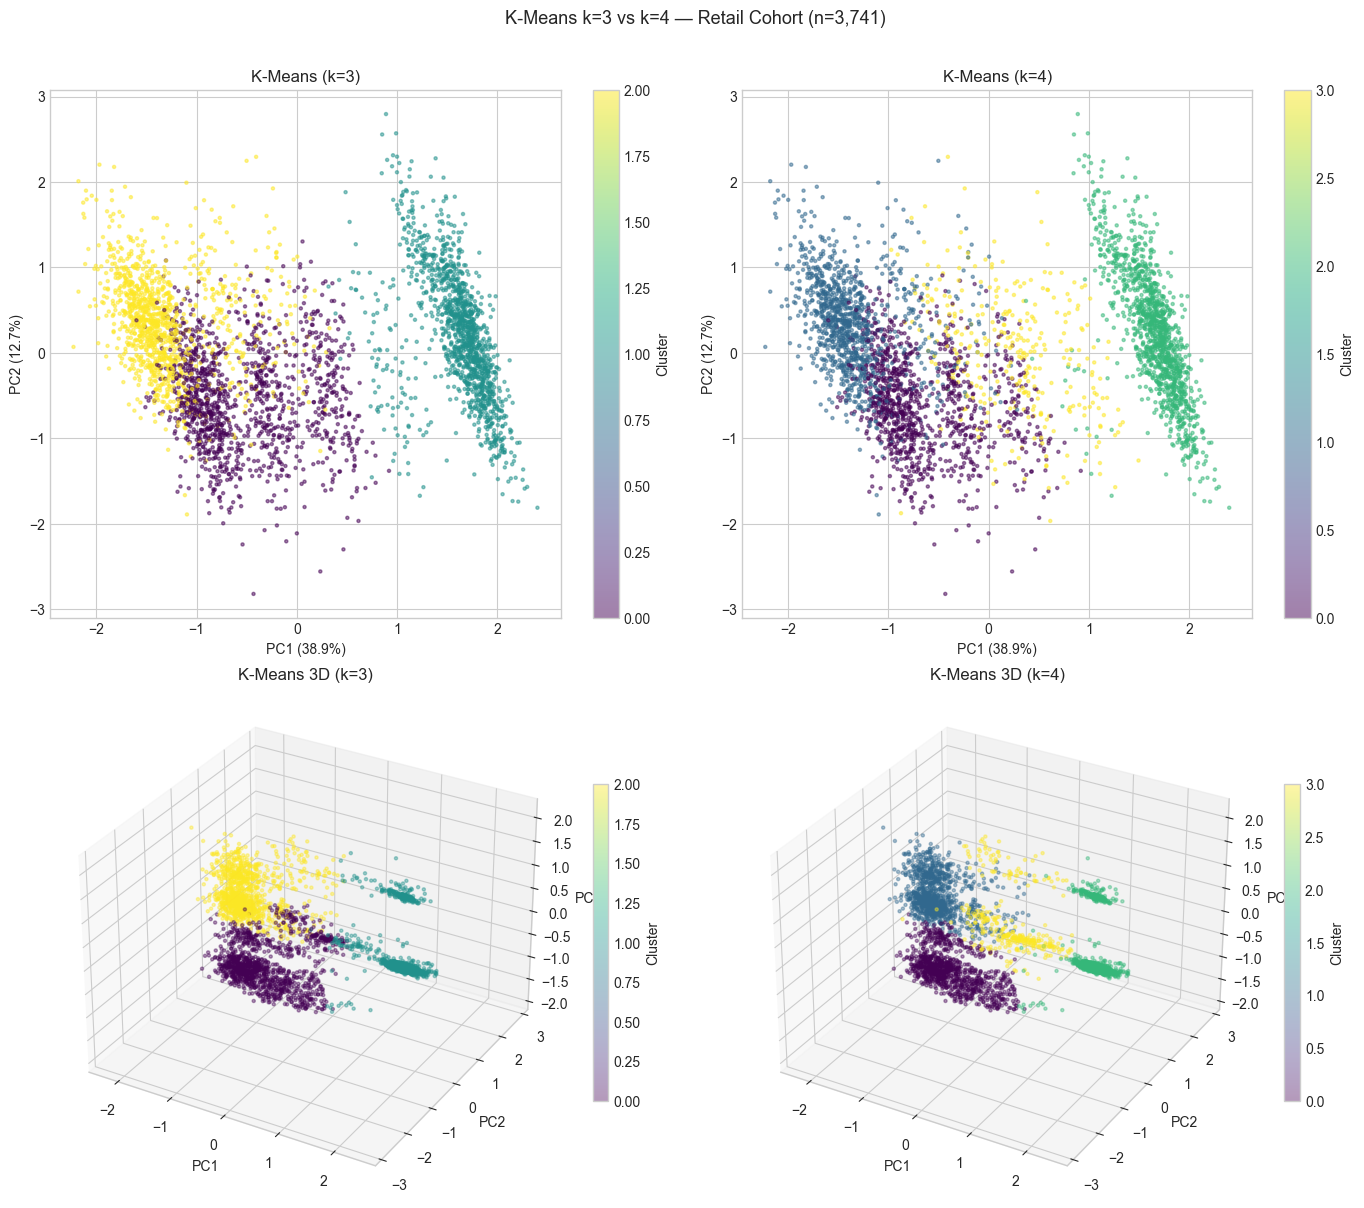

Saved: pca_k3_vs_k4_comparison.png


In [8]:
# --- k=3 vs k=4: 2D and 3D PCA scatter comparison ---
pca2 = PCA(n_components=2, random_state=42)
X_2d_cmp = pca2.fit_transform(X_retail)
var2_cmp = pca2.explained_variance_ratio_

pca3_cmp = PCA(n_components=3, random_state=42)
X_3d_cmp = pca3_cmp.fit_transform(X_retail)
var3_cmp = pca3_cmp.explained_variance_ratio_

fig = plt.figure(figsize=(14, 12))
fig.suptitle('K-Means k=3 vs k=4 — Retail Cohort (n=3,741)', fontsize=13, y=1.01)

# ── 2D: k=3 ──
ax1 = fig.add_subplot(2, 2, 1)
sc1 = ax1.scatter(X_2d_cmp[:, 0], X_2d_cmp[:, 1],
                  c=km3.labels_, cmap='viridis', alpha=0.5, s=5)
ax1.set_xlabel(f'PC1 ({var2_cmp[0]:.1%})')
ax1.set_ylabel(f'PC2 ({var2_cmp[1]:.1%})')
ax1.set_title('K-Means (k=3)')
plt.colorbar(sc1, ax=ax1, label='Cluster')

# ── 2D: k=4 ──
ax2 = fig.add_subplot(2, 2, 2)
sc2 = ax2.scatter(X_2d_cmp[:, 0], X_2d_cmp[:, 1],
                  c=km4.labels_, cmap='viridis', alpha=0.5, s=5)
ax2.set_xlabel(f'PC1 ({var2_cmp[0]:.1%})')
ax2.set_ylabel(f'PC2 ({var2_cmp[1]:.1%})')
ax2.set_title('K-Means (k=4)')
plt.colorbar(sc2, ax=ax2, label='Cluster')

# ── 3D: k=3 ──
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
sc3 = ax3.scatter(X_3d_cmp[:, 0], X_3d_cmp[:, 1], X_3d_cmp[:, 2],
                  c=km3.labels_, cmap='viridis', alpha=0.4, s=5)
ax3.set_xlabel(f'PC1')
ax3.set_ylabel(f'PC2')
ax3.set_zlabel(f'PC3')
ax3.set_title('K-Means 3D (k=3)')
fig.colorbar(sc3, ax=ax3, label='Cluster', shrink=0.6)

# ── 3D: k=4 ──
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
sc4 = ax4.scatter(X_3d_cmp[:, 0], X_3d_cmp[:, 1], X_3d_cmp[:, 2],
                  c=km4.labels_, cmap='viridis', alpha=0.4, s=5)
ax4.set_xlabel(f'PC1')
ax4.set_ylabel(f'PC2')
ax4.set_zlabel(f'PC3')
ax4.set_title('K-Means 3D (k=4)')
fig.colorbar(sc4, ax=ax4, label='Cluster', shrink=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_k3_vs_k4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_k3_vs_k4_comparison.png")

## 5. Mô hình cuối: K-Means++ k=4 trên nhóm retail

In [9]:
# Final K-Means++ k=4 fit on retail cohort
km_final = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=42)
km_final.fit(X_retail)

# Inline canonicalisation: map raw labels to stable behavioural identifiers
# so cluster numbers are consistent with lecture materials
_meds  = pd.DataFrame(X_retail, columns=df_retail.columns).groupby(km_final.labels_).median()
c1_raw = int(_meds['ReturnRate'].idxmax())                           # highest ReturnRate → High-Return Actives (index 1)
_rem   = [l for l in range(4) if l != c1_raw]
c2_raw = int(_meds.loc[_rem, 'BasketSizeCV'].idxmin())               # single purchase ⇒ BasketSizeCV≈0 → One-Time Explorers (index 2)
_rem   = [l for l in _rem if l != c2_raw]
c0_raw = int(_meds.loc[_rem, 'MonthlyOrderRate'].idxmax())           # burst cadence → Seasonal Intensives (index 0)
c3_raw = [l for l in _rem if l != c0_raw][0]                         # leftover → Occasional Loyalists (index 3)

_map      = {c0_raw: 0, c1_raw: 1, c2_raw: 2, c3_raw: 3}
labels_k4 = np.array([_map[l] for l in km_final.labels_])

cluster_names = {0: 'Seasonal Intensives', 1: 'High-Return Actives',
                 2: 'One-Time Explorers', 3: 'Occasional Loyalists'}

unique, counts = np.unique(labels_k4, return_counts=True)
n_retail = len(labels_k4)
print('Cluster sizes (retail cohort):')
for c, n in zip(unique, counts):
    print(f'  C{c} — {cluster_names[c]}: {n:,} ({100*n/n_retail:.1f}%)')
print(f"\nFinal k=4 metrics:")
print(f"  Silhouette       : {metrics_df.loc[4, 'Silhouette']:.4f}")
print(f"  Davies-Bouldin   : {metrics_df.loc[4, 'DaviesBouldin']:.4f}")
print(f"  Calinski-Harabasz: {metrics_df.loc[4, 'CalinskiHarabasz']:.1f}")

Cluster sizes (retail cohort):
  C0 — Seasonal Intensives: 330 (8.8%)
  C1 — High-Return Actives: 1,107 (29.6%)
  C2 — One-Time Explorers: 1,257 (33.6%)
  C3 — Occasional Loyalists: 1,047 (28.0%)

Final k=4 metrics:
  Silhouette       : 0.2436
  Davies-Bouldin   : 1.7641
  Calinski-Harabasz: 1066.4


## 6. Trực quan hoá các cluster

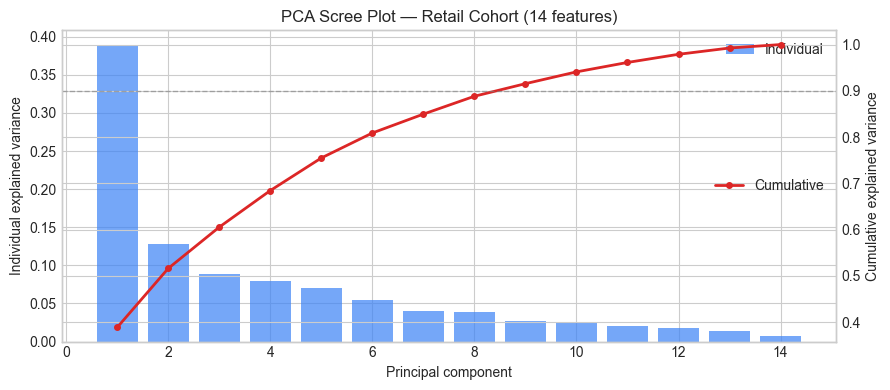

Variance explained: PC1-5 = 75.5%   PC1-10 = 94.1%


In [10]:
# --- Scree plot (retail cohort) ---
pca_full = PCA(random_state=42).fit(X_retail)
var_ratio = pca_full.explained_variance_ratio_
cumvar    = np.cumsum(var_ratio)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(var_ratio)+1), var_ratio, color='#3B82F6', alpha=0.7, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#DC2626', lw=2, ms=4, label='Cumulative')
ax2.axhline(0.9, color='gray', ls='--', lw=1, alpha=0.6)
ax2.set_ylabel('Cumulative explained variance')
ax.set_xlabel('Principal component')
ax.set_ylabel('Individual explained variance')
ax.set_title('PCA Scree Plot — Retail Cohort (14 features)')
ax.legend(loc='upper right')
ax2.legend(loc='center right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'scree_retail.png', dpi=150, bbox_inches='tight')
plt.show()
pc5_cum = cumvar[4]
pc10_cum = cumvar[9] if len(cumvar) > 9 else cumvar[-1]
print(f"Variance explained: PC1-5 = {pc5_cum:.1%}   PC1-10 = {pc10_cum:.1%}")

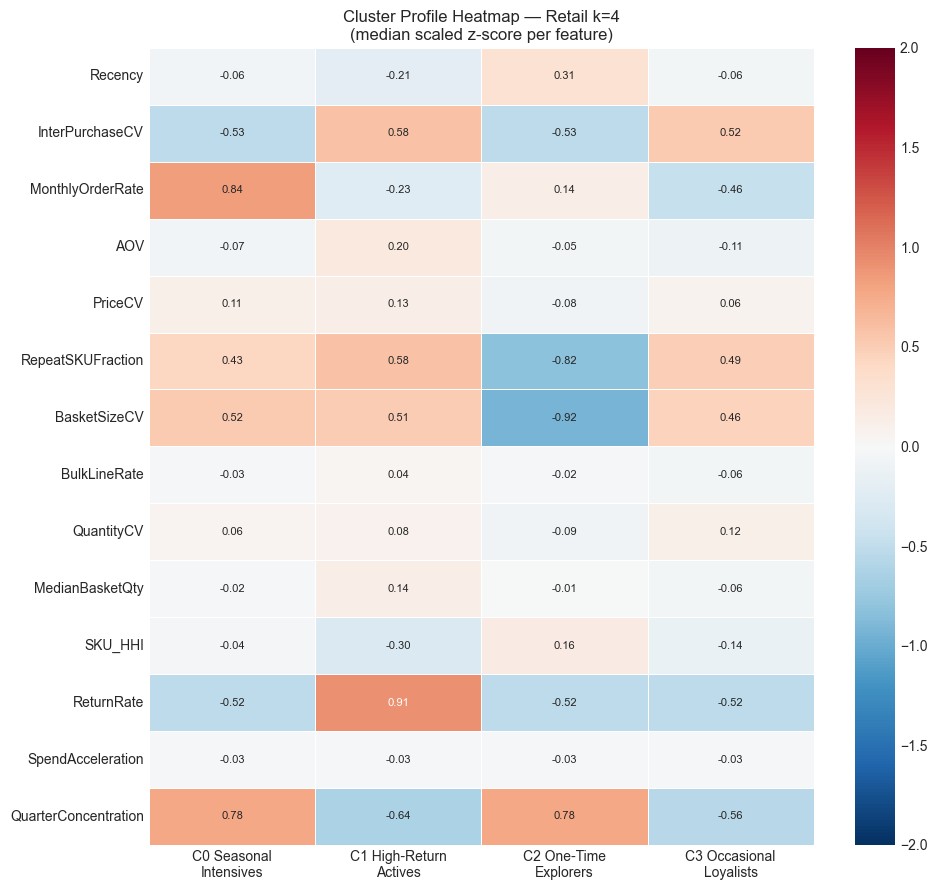

Saved: /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/figures/03_modeling/cluster_profile_retail_k4.png


In [11]:
# --- Cluster profile heatmap (retail k=4) ---
# Wong CVD-safe palette: C0=orange, C1=blue, C2=bluish-green, C3=reddish-purple
from visual_style import CLUSTER_COLORS
CLUSTER_LABELS = ['C0 Seasonal\nIntensives', 'C1 High-Return\nActives',
                  'C2 One-Time\nExplorers', 'C3 Occasional\nLoyalists']

med4_all = cluster_medians(X_retail, labels_k4, feat_cols)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(med4_all.T, cmap='RdBu_r', center=0, vmin=-2, vmax=2,
            annot=True, fmt='.2f', linewidths=0.4, annot_kws={'size': 8},
            xticklabels=CLUSTER_LABELS, ax=ax)
ax.set_title('Cluster Profile Heatmap — Retail k=4\n(median scaled z-score per feature)', fontsize=12)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_profile_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", FIG_DIR / 'cluster_profile_retail_k4.png')

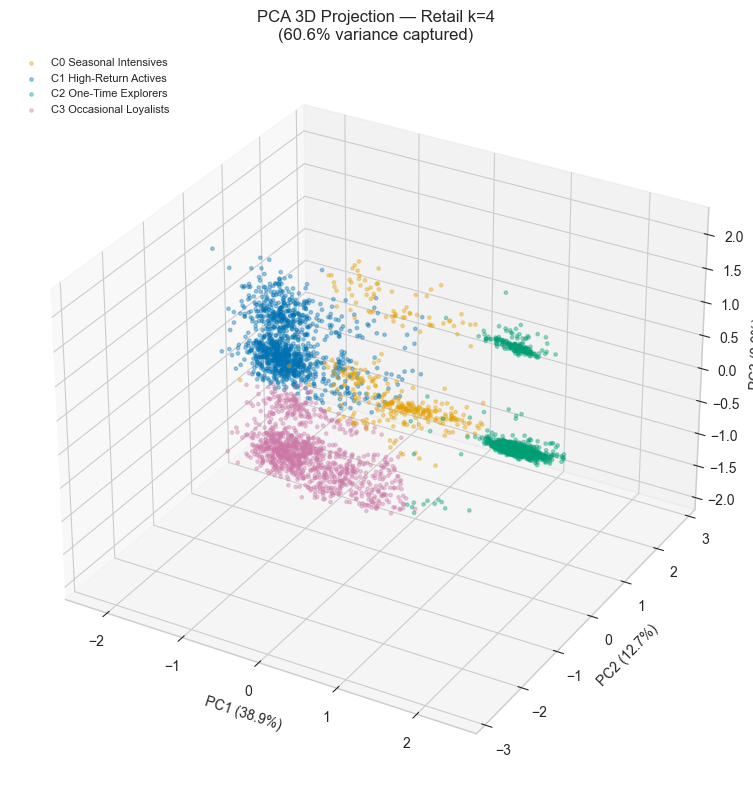

Saved: /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/figures/03_modeling/pca_scatter_3d_retail_k4.png


In [12]:
# --- PCA 3D scatter ---
pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_retail)
var3 = pca3.explained_variance_ratio_

fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection='3d')
for c in range(4):
    mask = labels_k4 == c
    ax3d.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                 c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c].replace('\n',' '),
                 alpha=0.35, s=6)
ax3d.set_xlabel(f'PC1 ({var3[0]:.1%})')
ax3d.set_ylabel(f'PC2 ({var3[1]:.1%})')
ax3d.set_zlabel(f'PC3 ({var3[2]:.1%})')
ax3d.set_title(f'PCA 3D Projection — Retail k=4\n({sum(var3):.1%} variance captured)')
ax3d.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_scatter_3d_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", FIG_DIR / 'pca_scatter_3d_retail_k4.png')

## 7. Đặc điểm các phân khúc

| Cluster | Tên | n | % | Tín hiệu đặc trưng | Nhãn RFM (sai) |
|---------|-----|---|---|---------------------|-----------------|
| C0 | **Seasonal Intensives** | 330 | 8,8% | MonthlyOrderRate cao, QuarterConcentration cao (mua dồn theo mùa Q4) | "Loyal (seasonal)" |
| C1 | **High-Return Actives** | 1.107 | 29,6% | ReturnRate rất cao, hoạt động trải rộng qua các quý, LTV cao nhất | "Champions" (sai) |
| C2 | **One-Time Explorers** | 1.257 | 33,6% | BasketSizeCV≈0, RepeatSKUFraction≈0, Recency cao (mua một lần) | "At-Risk" |
| C3 | **Occasional Loyalists** | 1.047 | 28,0% | Không hoàn trả, gắn bó lâu, tần suất vừa | "Potential Loyalist" |
| B2B | **Wholesale Procurement** | 179 | 4,6% | SKU_HHI > 0,5 (quy tắc), BulkLineRate cao, QuantityCV gần 0 | "VIP/Champions" |

**Phát hiện thương mại chính:** 29,6% khách hàng retail (C1 High-Return Actives) có tỉ lệ huỷ hoá đơn trung vị 25%. RFM chỉ đếm hoá đơn hợp lệ và dùng Monetary ròng, nhưng không mã hoá xu hướng hoàn trả và không tách C1 thành phân khúc riêng.

## 8. Lưu kết quả

In [13]:
# Export canonical assignments without relabelling side effects.
retail_assignments = pd.DataFrame({
    'CustomerID': df_retail.index.astype(int),
    'cluster': labels_k4,
    'segment': [cluster_names[c] for c in labels_k4],
})
retail_assignments.to_csv(wpath('processed/cluster_assignments_retail_k4.csv'), index=False)

full_assignments = pd.DataFrame({
    'CustomerID': df_scaled.index.astype(int),
    'cluster': -1,
    'segment': 'Wholesale-like Proxy',
}).set_index('CustomerID')
full_assignments.loc[df_retail.index, 'cluster'] = labels_k4
full_assignments.loc[df_retail.index, 'segment'] = [cluster_names[c] for c in labels_k4]
full_assignments.reset_index().to_csv(wpath('processed/cluster_assignments_full.csv'), index=False)

print(f'Saved canonical retail assignments: {len(retail_assignments):,}')
print(f'Saved canonical full assignments:   {len(full_assignments):,}')

Saved canonical retail assignments: 3,741
Saved canonical full assignments:   3,920


## Tổng kết

| Bước | Kết quả |
|------|---------|
| Bộ lọc B2B giai đoạn 1 | 179 tài khoản bị cô lập (SKU_HHI > 0,5) |
| Nhóm retail | 3.741 khách hàng, 14 đặc trưng |
| k được chọn | **4** (thương mại: k nhỏ nhất giải quyết được cả 4 nhóm; k=3 gộp nhóm mùa vụ vào đa số không hoàn trả) |
| Silhouette (k=4) | 0,2436 |
| Davies-Bouldin | 1,7641 |
| Calinski-Harabasz | 1.066,4 |
| C0 Seasonal Intensives | 330 (8,8%) |
| C1 High-Return Actives | 1.107 (29,6%) |
| C2 One-Time Explorers | 1.257 (33,6%) |
| C3 Occasional Loyalists | 1.047 (28,0%) |

**Tiếp theo: `04_shap_analysis.ipynb` - giải thích tại sao K-Means gán mỗi khách hàng vào cluster đó**